                                     flight Delay Analytics using Python

 🚀 Sprint 1 – Data Understanding & Preparation

📄 2. Dataset Understanding

In [80]:
import numpy as np
import pandas as pd


dff = pd.read_csv('Flight_Delays_50K.csv')

In [81]:
dff.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,5,14,4,US,1721,N174US,CLT,SMF,1810,...,2043.0,4.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,11,29,7,MQ,3363,N902MQ,LEX,ORD,1837,...,1942.0,17.0,0,0,NaN,0.0,0.0,0.0,17.0,0.0
2,2015,2,10,2,US,1933,N562UW,PHL,ORD,730,...,834.0,-28.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,12,21,1,UA,1929,N460UA,SEA,EWR,622,...,1414.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,5,7,4,DL,1478,N67171,ATL,PHL,725,...,920.0,-5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
print(dff.shape)  #number of rows and columns

(50000, 31)


In [83]:
dff.columns        #features of dataset

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [84]:
dff.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 50000 non-null  int64  
 1   MONTH                50000 non-null  int64  
 2   DAY                  50000 non-null  int64  
 3   DAY_OF_WEEK          50000 non-null  int64  
 4   AIRLINE              50000 non-null  object 
 5   FLIGHT_NUMBER        50000 non-null  int64  
 6   TAIL_NUMBER          49871 non-null  object 
 7   ORIGIN_AIRPORT       50000 non-null  object 
 8   DESTINATION_AIRPORT  50000 non-null  object 
 9   SCHEDULED_DEPARTURE  50000 non-null  int64  
 10  DEPARTURE_TIME       49234 non-null  float64
 11  DEPARTURE_DELAY      49234 non-null  float64
 12  TAXI_OUT             49215 non-null  float64
 13  WHEELS_OFF           49215 non-null  float64
 14  SCHEDULED_TIME       50000 non-null  float64
 15  ELAPSED_TIME         49085 non-null 

🐼 3. DataFrame Exploration

In [85]:
dff.shape

(50000, 31)

In [86]:
dff.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [87]:
dff.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,50000.0,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,49234.000000,49234.000000,49215.000000,49215.000000,...,50000.00000,49182.000000,49085.00000,50000.000000,50000.000000,9100.000000,9100.000000,9100.000000,9100.000000,9100.000000
mean,2015.0,6.543440,15.68610,3.941880,2177.016720,1326.620920,1330.928728,9.086526,16.019344,1352.902387,...,1489.85644,1473.280631,3.99945,0.002420,0.015880,13.232418,0.071429,18.419121,22.633736,2.905604
std,0.0,3.395736,8.77768,1.992019,1759.888911,483.235737,496.210684,35.464728,8.805555,497.512045,...,505.73494,523.907408,37.75498,0.049134,0.125013,26.820545,1.793296,45.155575,41.287011,19.951584
min,2015.0,1.000000,1.00000,1.000000,1.000000,3.000000,1.000000,-55.000000,1.000000,1.000000,...,1.00000,1.000000,-70.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,4.000000,8.00000,2.000000,733.000000,915.000000,919.000000,-5.000000,11.000000,933.000000,...,1108.00000,1056.000000,-13.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,7.000000,16.00000,4.000000,1686.000000,1324.000000,1327.000000,-2.000000,14.000000,1340.000000,...,1518.00000,1510.000000,-5.00000,0.000000,0.000000,2.000000,0.000000,2.000000,3.000000,0.000000
75%,2015.0,9.000000,23.00000,6.000000,3246.000000,1730.000000,1737.000000,7.000000,19.000000,1751.000000,...,1915.00000,1913.000000,8.00000,0.000000,0.000000,18.000000,0.000000,19.000000,28.000000,0.000000
max,2015.0,12.000000,31.00000,7.000000,8410.000000,2359.000000,2400.000000,1515.000000,149.000000,2400.000000,...,2359.00000,2400.000000,1574.00000,1.000000,1.000000,532.000000,129.000000,1515.000000,765.000000,510.000000


In [88]:
dff.columns.tolist()

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [89]:
dff.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,50000.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,50000.0,6.543440,3.395736,1.0,4.0,7.0,9.0,12.0
DAY,50000.0,15.686100,8.777680,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,50000.0,3.941880,1.992019,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,50000.0,2177.016720,1759.888911,1.0,733.0,1686.0,3246.0,8410.0
SCHEDULED_DEPARTURE,50000.0,1326.620920,483.235737,3.0,915.0,1324.0,1730.0,2359.0
DEPARTURE_TIME,49234.0,1330.928728,496.210684,1.0,919.0,1327.0,1737.0,2400.0
DEPARTURE_DELAY,49234.0,9.086526,35.464728,-55.0,-5.0,-2.0,7.0,1515.0
TAXI_OUT,49215.0,16.019344,8.805555,1.0,11.0,14.0,19.0,149.0
WHEELS_OFF,49215.0,1352.902387,497.512045,1.0,933.0,1340.0,1751.0,2400.0


🧹 4. Data Cleaning

In [90]:
dff.isnull().sum() #no of null values

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE                    0
FLIGHT_NUMBER              0
TAIL_NUMBER              129
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME           766
DEPARTURE_DELAY          766
TAXI_OUT                 785
WHEELS_OFF               785
SCHEDULED_TIME             0
ELAPSED_TIME             915
AIR_TIME                 915
DISTANCE                   0
WHEELS_ON                818
TAXI_IN                  818
SCHEDULED_ARRIVAL          0
ARRIVAL_TIME             818
ARRIVAL_DELAY            915
DIVERTED                   0
CANCELLED                  0
CANCELLATION_REASON    49206
AIR_SYSTEM_DELAY       40900
SECURITY_DELAY         40900
AIRLINE_DELAY          40900
LATE_AIRCRAFT_DELAY    40900
WEATHER_DELAY          40900
dtype: int64

In [91]:
dff['TAIL_NUMBER'].fillna("N/A",inplace=True) #fill null values with n/a

/var/folders/3m/vgv340g94sn32dzby4sz4_tm0000gn/T/ipykernel_31303/2937493369.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dff['TAIL_NUMBER'].fillna("N/A",inplace=True) #fill null values with n/a


In [92]:
print(dff['TAIL_NUMBER'].isnull().sum()) #null values became zero

0


In [ ]:
dff['DEPARTURE_TIME'] = dff['DEPARTURE_TIME'].replace(2400, 0)  #correct date format

In [94]:
dff['DEPARTURE_TIME'] = pd.to_datetime(
    dff['DEPARTURE_TIME'].astype('Int64').astype(str).str.zfill(4),
    format='%H%M',
    errors='coerce'
).dt.time   #converting to correct datetime format

In [95]:
dff['DEPARTURE_TIME'].head() #done

0    18:30:00
1    19:06:00
2    07:25:00
3    06:23:00
4    07:28:00
Name: DEPARTURE_TIME, dtype: object

In [96]:
dff['CANCELLATION_REASON'] = dff['CANCELLATION_REASON'].fillna('NOT_CANCELLED') #filled null values

In [97]:
delay_cause_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
dff[delay_cause_cols] = dff[delay_cause_cols].fillna(0)  #event never happened 

In [98]:
print("Remaining missing values after treatment:") 
print(dff.isnull().sum()[dff.isnull().sum() > 0])     

Remaining missing values after treatment:
DEPARTURE_TIME     766
DEPARTURE_DELAY    766
TAXI_OUT           785
WHEELS_OFF         785
ELAPSED_TIME       915
AIR_TIME           915
WHEELS_ON          818
TAXI_IN            818
ARRIVAL_TIME       818
ARRIVAL_DELAY      915
dtype: int64


In [99]:
full_row_dupes = dff.duplicated().sum()
print('Fully duplicated rows:', full_row_dupes) #row duplicates

Fully duplicated rows: 0


In [100]:
key_cols = ['YEAR', 'MONTH', 'DAY', 'AIRLINE', 'FLIGHT_NUMBER', 'ORIGIN_AIRPORT']
logical_dupes = dff.duplicated(subset=key_cols).sum()
print('Logical duplicates - same flight, same day:', logical_dupes) #column logical duplicates 

Logical duplicates - same flight, same day: 0


In [101]:
dff['FLIGHT_DATE'] = pd.to_datetime(dict(year=dff['YEAR'], month=dff['MONTH'], day=dff['DAY']))
dff[['YEAR', 'MONTH', 'DAY', 'FLIGHT_DATE']].head()     #correcting dtype and add into single column for easy usage and understanding

,YEAR,MONTH,DAY,FLIGHT_DATE
0,2015,5,14,2015-05-14
1,2015,11,29,2015-11-29
2,2015,2,10,2015-02-10
3,2015,12,21,2015-12-21
4,2015,5,7,2015-05-07


In [ ]:
categorical_cols = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON', 'TAIL_NUMBER']
for c in categorical_cols:
    dff[c] = dff[c].astype('category')    #checking correct  datatypes 

dff[categorical_cols].dtypes

AIRLINE                category
ORIGIN_AIRPORT         category
DESTINATION_AIRPORT    category
CANCELLATION_REASON    category
TAIL_NUMBER            category
dtype: object

In [103]:
checks = {
    'DAY_OF_WEEK not in 1-7'              : (~dff['DAY_OF_WEEK'].between(1, 7)).sum(),
    'MONTH not in 1-12'                   : (~dff['MONTH'].between(1, 12)).sum(),
    'DISTANCE <= 0'                       : (dff['DISTANCE'] <= 0).sum(),
    'SCHEDULED_TIME <= 0'                 : (dff['SCHEDULED_TIME'] <= 0).sum(),
    'TAXI_OUT < 0'                        : (dff['TAXI_OUT'] < 0).sum(),
    'TAXI_IN < 0'                         : (dff['TAXI_IN'] < 0).sum(),
    'AIR_TIME <= 0'                       : (dff['AIR_TIME'] <= 0).sum(),
    'SCHEDULED_DEPARTURE not in [0,2400]' : (~dff['SCHEDULED_DEPARTURE'].between(0, 2400)).sum(),
    'SCHEDULED_ARRIVAL not in [0,2400]'   : (~dff['SCHEDULED_ARRIVAL'].between(0, 2400)).sum(),
    'CANCELLED not in {0,1}'              : (~dff['CANCELLED'].isin([0, 1])).sum(),
    'DIVERTED not in {0,1}'               : (~dff['DIVERTED'].isin([0, 1])).sum(),
}
pd.Series(checks, name='invalid_row_count')         #checks invalid values count

DAY_OF_WEEK not in 1-7                 0
MONTH not in 1-12                      0
DISTANCE <= 0                          0
SCHEDULED_TIME <= 0                    0
TAXI_OUT < 0                           0
TAXI_IN < 0                            0
AIR_TIME <= 0                          0
SCHEDULED_DEPARTURE not in [0,2400]    0
SCHEDULED_ARRIVAL not in [0,2400]      0
CANCELLED not in {0,1}                 0
DIVERTED not in {0,1}                  0
Name: invalid_row_count, dtype: int64

In [104]:
is_numeric_code = dff['ORIGIN_AIRPORT'].astype(str).str.match(r'^\d+$')
print('Rows with a numeric (non-IATA) origin airport code:', is_numeric_code.sum(),
      f"({is_numeric_code.mean()*100:.2f}% of rows)")
dff.loc[is_numeric_code, 'ORIGIN_AIRPORT'].astype(str).unique()[:10]   #no of inconsistent categorical values rows in origin airport

Rows with a numeric (non-IATA) origin airport code: 4228 (8.46% of rows)


array(['12889', '13198', '11697', '12266', '13232', '12478', '10397',
       '15323', '14100', '14457'], dtype=object)

In [105]:
is_numeric_dest = dff['DESTINATION_AIRPORT'].astype(str).str.match(r'^\d+$')
print('Rows with numeric destination code:', is_numeric_dest.sum(),
      f"({is_numeric_dest.mean()*100:.2f}% of rows)")        #no of inconsistant value rows in destination airport

Rows with numeric destination code: 4228 (8.46% of rows)


In [ ]:
dff['ORIGIN_CODE_FORMAT'] = np.where(is_numeric_code, 'DOT_NUMERIC_ID', 'IATA')
dff['ORIGIN_CODE_FORMAT'] = dff['ORIGIN_CODE_FORMAT'].astype('category')

dff['DEST_CODE_FORMAT'] = np.where(is_numeric_dest, 'DOT_NUMERIC_ID', 'IATA')
dff['DEST_CODE_FORMAT'] = dff['DEST_CODE_FORMAT'].astype('category')

dff[['ORIGIN_CODE_FORMAT', 'DEST_CODE_FORMAT']].apply(lambda s: s.value_counts())   #flagged inconsistant value rows

,ORIGIN_CODE_FORMAT,DEST_CODE_FORMAT
IATA,45772,45772
DOT_NUMERIC_ID,4228,4228


ORIGIN_AIRPORT/DESTINATION_AIRPORT contain two different coding schemes mixed together: standard IATA 3-letter codes and numeric DOT airport IDs. No official lookup table is available to safely convert one to the other, so instead of guessing, both formats were flagged via new ORIGIN_CODE_FORMAT/DEST_CODE_FORMAT columns. This is documented as a data-quality issue for the data source owner, and AIRLINE was separately confirmed to be consistently formatted with no fix needed.

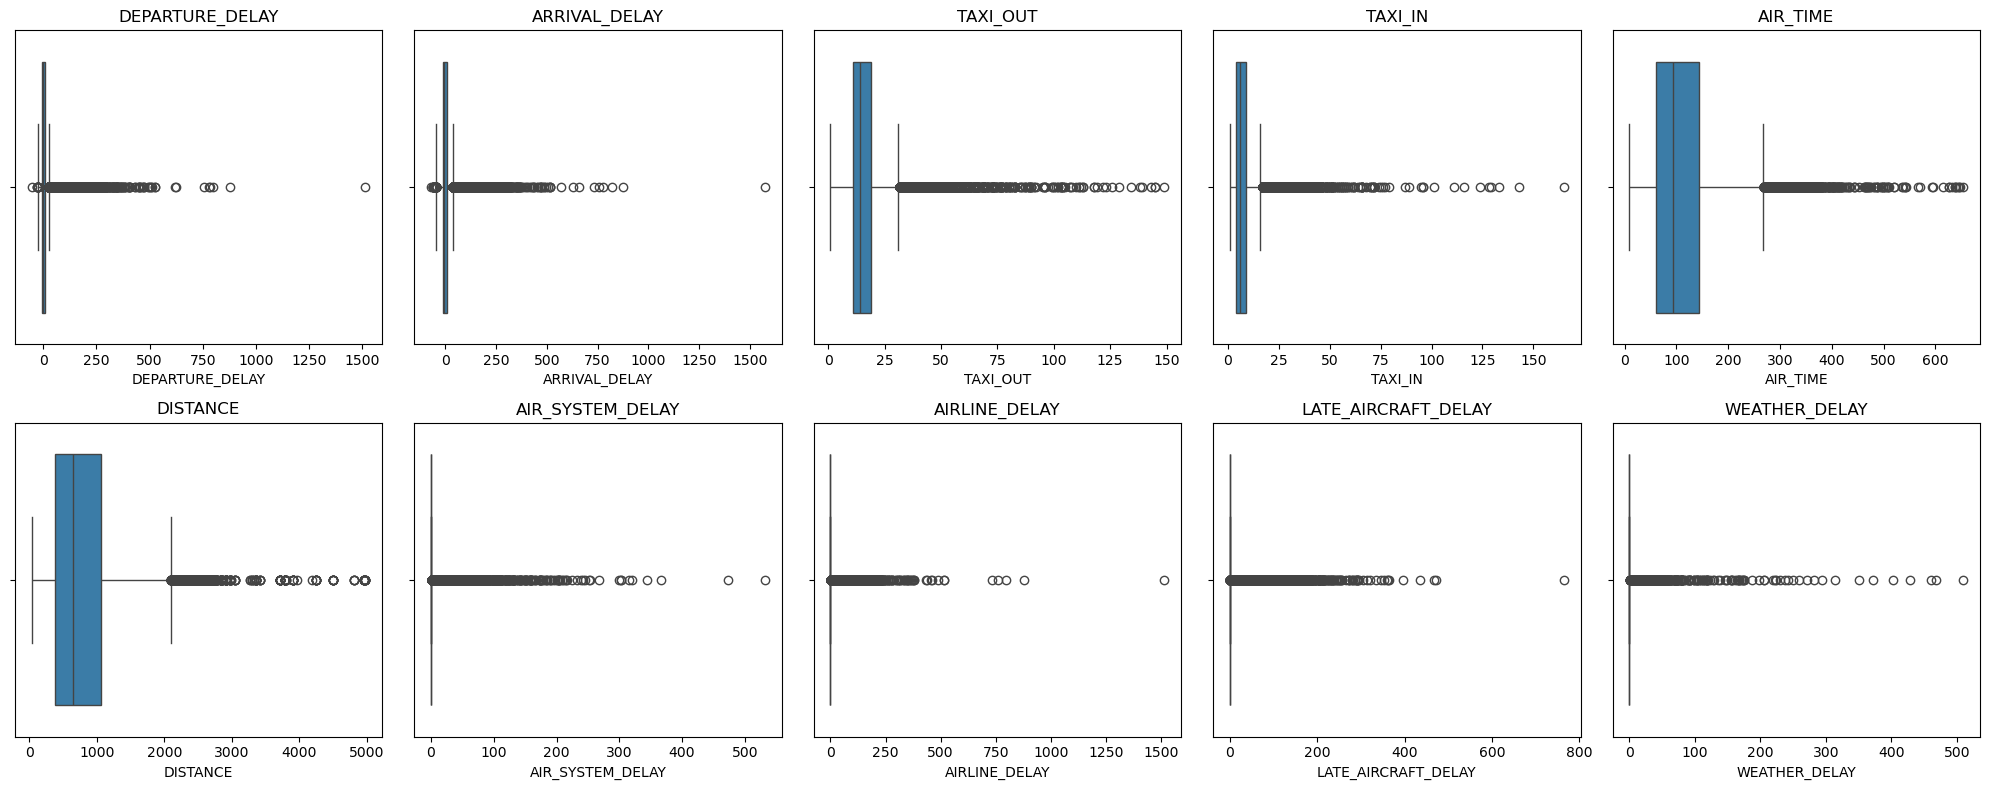

In [107]:
#outliers analysis
import seaborn as sns
import matplotlib.pyplot as plt
outlier_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME', 'DISTANCE',
                 'AIR_SYSTEM_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']



fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, outlier_cols):
    sns.boxplot(x=dff[col], ax=ax, color='#2980b9')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
def iqr_outlier_summary(series, label):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    return {
        'column': label, 'Q1': round(q1, 1), 'Q3': round(q3, 1), 'IQR': round(iqr, 1),
        'lower_fence': round(lower, 1), 'upper_fence': round(upper, 1),
        'outliers': n_outliers, 'pct_outliers': round(n_outliers / len(s) * 100, 2),
    }

outlier_report = pd.DataFrame([iqr_outlier_summary(dff[c], c) for c in outlier_cols]).set_index('column')     #outliers report
outlier_report

,Q1,Q3,IQR,lower_fence,upper_fence,outliers,pct_outliers
column,,,,,,,
DEPARTURE_DELAY,-5.0,7.0,12.0,-23.0,25.0,6261,12.72
ARRIVAL_DELAY,-13.0,8.0,21.0,-44.5,39.5,4317,8.79
TAXI_OUT,11.0,19.0,8.0,-1.0,31.0,2370,4.82
TAXI_IN,4.0,9.0,5.0,-3.5,16.5,2366,4.81
AIR_TIME,61.0,144.0,83.0,-63.5,268.5,2641,5.38
DISTANCE,373.0,1066.0,693.0,-666.5,2105.5,3020,6.04
AIR_SYSTEM_DELAY,0.0,0.0,0.0,0.0,0.0,4824,9.65
AIRLINE_DELAY,0.0,0.0,0.0,0.0,0.0,4847,9.69
LATE_AIRCRAFT_DELAY,0.0,0.0,0.0,0.0,0.0,4786,9.57


In [ ]:
extreme_upper = q3 + 3 * iqr
dff['EXTREME_DELAY_FLAG'] = (dff['ARRIVAL_DELAY'] > extreme_upper).fillna(False)

print(f"Extreme-delay threshold (3x IQR): {extreme_upper:.1f} minutes")
print("Flights flagged as extreme delays:", dff['EXTREME_DELAY_FLAG'].sum()) 

Extreme-delay threshold (3x IQR): 71.0 minutes
Flights flagged as extreme delays: 2132


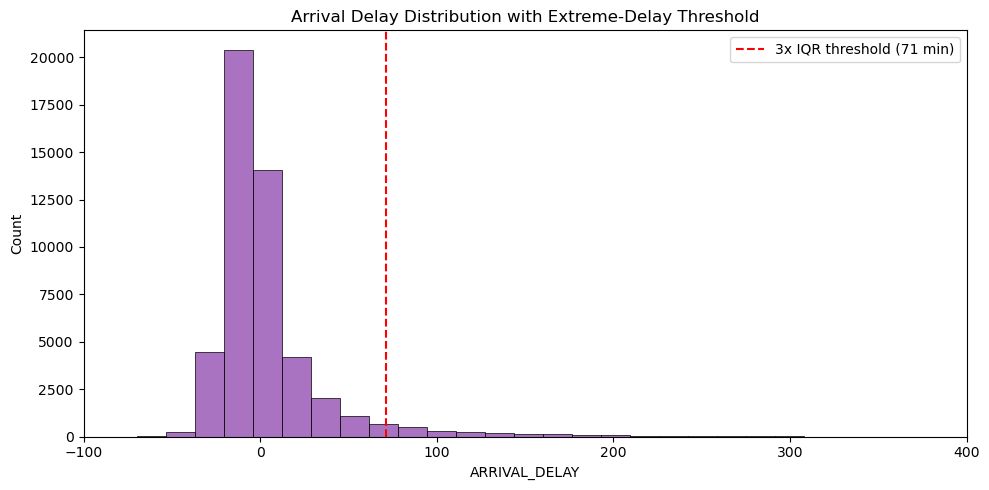

In [110]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(dff['ARRIVAL_DELAY'].dropna(), bins=100, color='#8e44ad', ax=ax)
ax.axvline(extreme_upper, color='red', linestyle='--', label=f'3x IQR threshold ({extreme_upper:.0f} min)')
ax.set_xlim(-100, 400)
ax.set_title('Arrival Delay Distribution with Extreme-Delay Threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#data validation

validation = {}

# 1. Row count preserved (no rows silently dropped anywhere in the process)
validation['Row count preserved (50,000)'] = (dff.shape[0] == 50000)

# 2. No missing values outside the columns we deliberately left as structural NaN
structural_na_cols = ['DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
                       'ELAPSED_TIME', 'AIR_TIME', 'WHEELS_ON', 'TAXI_IN', 'ARRIVAL_TIME', 'ARRIVAL_DELAY']
non_structural_missing = dff.drop(columns=structural_na_cols).isnull().sum().sum()
validation['No missing values outside structural columns'] = (non_structural_missing == 0)

# 3. Dtype corrections from Step 8 actually applied
validation['Categorical columns use category dtype'] = all(
    str(dff[c].dtype) == 'category' for c in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON'])
validation['FLIGHT_DATE is datetime'] = pd.api.types.is_datetime64_any_dtype(dff['FLIGHT_DATE'])

# 4. No duplicate rows (re-confirm from Step 7)
validation['No full-row duplicates'] = (dff.duplicated().sum() == 0)

# 5. Range/validity checks from Step 9 still hold
validation['DISTANCE always positive'] = (dff['DISTANCE'] > 0).all()
validation['DAY_OF_WEEK within 1-7'] = dff['DAY_OF_WEEK'].between(1, 7).all()
validation['CANCELLED/DIVERTED are strictly 0/1'] = (
    dff['CANCELLED'].isin([0, 1]).all() and dff['DIVERTED'].isin([0, 1]).all())

validation_summary = pd.Series(validation, name='PASS')
validation_summary

Row count preserved (50,000)                    True
No missing values outside structural columns    True
Categorical columns use category dtype          True
FLIGHT_DATE is datetime                         True
No full-row duplicates                          True
DISTANCE always positive                        True
DAY_OF_WEEK within 1-7                          True
CANCELLED/DIVERTED are strictly 0/1             True
Name: PASS, dtype: bool

In [119]:
OUTPUT_PATH = 'Flight_Delays_50K_cleaned.csv'
dff.to_csv(OUTPUT_PATH, index=False)

print(f"Cleaned dataset exported: {OUTPUT_PATH}")
print(f"Final shape: {dff.shape[0]:,} rows x {dff.shape[1]} columns")
print("(Raw file Flight_Delays_50K.csv was never modified.)")

Cleaned dataset exported: Flight_Delays_50K_cleaned.csv
Final shape: 50,000 rows x 35 columns
(Raw file Flight_Delays_50K.csv was never modified.)


## Sprint 1 Complete

Summary of what was done:
- Cleaned 50,000-row flight operations dataset without deleting any rows
- Treated missing values based on documented root-cause analysis (structural vs. fillable)
- Verified zero duplicate records
- Corrected data types (category, datetime) for 6 columns
- Verified all numeric ranges are valid
- Flagged (not guessed at) an airport-code inconsistency affecting ~8.5% of rows
- Analyzed outliers using IQR + boxplots/histogram; retained all outliers as genuine business signal
- Added EXTREME_DELAY_FLAG for future severe-delay analysis
- Exported cleaned dataset, ready for Sprint 2 (EDA & Visualization)